In [1]:
#instrumental variables example
#install package
#install.packages("ivpack")
install.packages("fixest")
#load package
#library(ivpack)
library(fixest)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [2]:
#read dataset
#data(card.data)
load("./card.data.rda")
View(card.data)

,id,nearc2,nearc4,educ,age,fatheduc,motheduc,weight,momdad14,sinmom14,⋯,wage,enroll,KWW,IQ,married,libcrd14,exper,lwage,expersq,region
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>
1,2,0,0,7,29,NA,NA,158413,1,0,⋯,548,0,15,NA,1,0,16,6.306275,256,661
2,3,0,0,12,27,8,8,380166,1,0,⋯,481,0,35,93,1,1,9,6.175867,81,661
3,4,0,0,12,34,14,12,367470,1,0,⋯,721,0,42,103,1,1,16,6.580639,256,661
4,5,1,1,11,27,11,12,380166,1,0,⋯,250,0,25,88,1,1,10,5.521461,100,662
5,6,1,1,12,34,8,7,367470,1,0,⋯,729,0,34,108,1,0,16,6.591674,256,662
6,7,1,1,12,26,9,12,380166,1,0,⋯,500,0,38,85,1,1,8,6.214608,64,662
7,8,1,1,18,33,14,14,367470,1,0,⋯,565,0,41,119,1,1,9,6.336826,81,662
8,9,1,1,14,29,14,14,496635,1,0,⋯,608,0,46,108,1,1,9,6.410175,81,662
9,10,1,1,12,28,12,12,367772,1,0,⋯,425,0,32,96,4,0,10,6.052089,100,662


[1] 0.6820598

[1] 13.52703

[1] 12.69801

[1] "Propotion of Compliers:"


[1] 0.1219293

[1] "ITT:"


[1] 0.1559075

[1] "Causal effect:"


[1] 1.278672

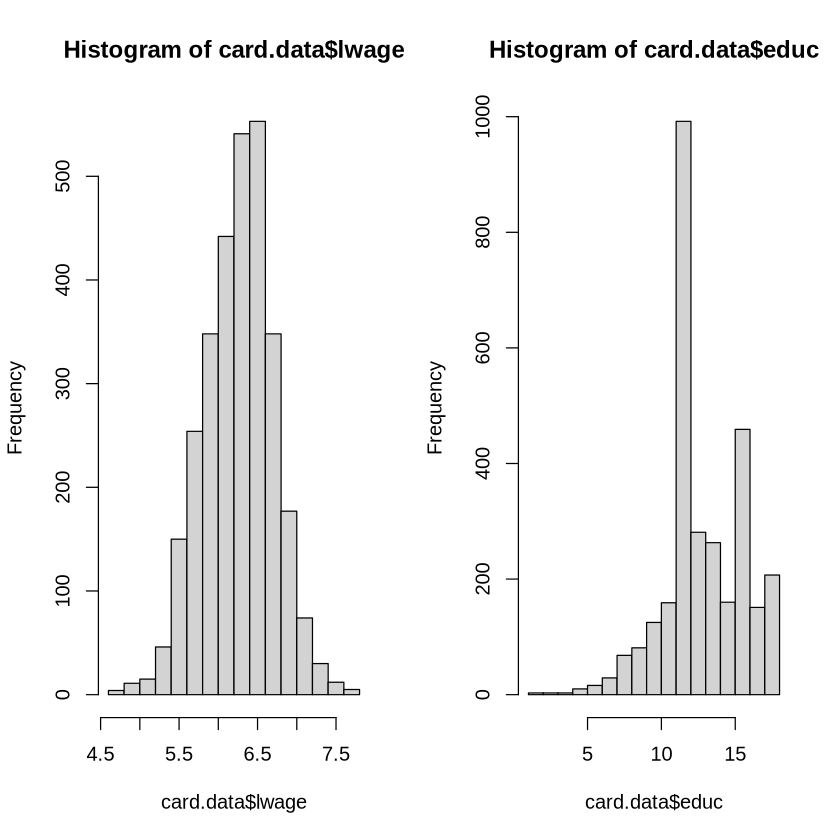

In [3]:
#IV is nearc4 (near 4 year college)
#outcome is lwage (log of wage)
#'treatment' is educ (number of years of education)

#summary stats
mean(card.data$nearc4)
par(mfrow=c(1,2))
hist(card.data$lwage)
hist(card.data$educ)

#is the IV associated with the treatment? strenght of IV
mean(card.data$educ[card.data$nearc4==1])
mean(card.data$educ[card.data$nearc4==0])


#make education binary
educ12<-card.data$educ>12

#estimate proportion of 'compliers'
propcomp<-mean(educ12[card.data$nearc4==1])-
  mean(educ12[card.data$nearc4==0])
print("Propotion of Compliers:")
propcomp

#intention to treat effect
itt<-mean(card.data$lwage[card.data$nearc4==1])-
  mean(card.data$lwage[card.data$nearc4==0])
print("ITT:")
itt

#complier average causal effect
print("Causal effect:")
itt/propcomp

In [4]:
#two stage least squares

#stage 1: regress A on Z
s1<-lm(educ12~card.data$nearc4)
## get predicted value of A given Z for each subject
predtx <-predict(s1, type = "response")
table(predtx)

#stage 2: regress Y on predicted value of A
lm(card.data$lwage~predtx)

predtx
0.422152560083594 0.544081831466147 
              957              2053 


Call:
lm(formula = card.data$lwage ~ predtx)

Coefficients:
(Intercept)       predtx  
      5.616        1.279  


In [22]:
# Using fixest (ivpack is dead)
card.data["educ12"]<-educ12
est_iv = feols( lwage ~ 1 | educ12 ~ nearc4 , 
                data=card.data)
est_iv

TSLS estimation
|- D.V.   : lwage
|- Endo.  : educ12
|- Instr. : nearc4
|
|=> Second Stage
|   Dep. Var.: lwage
Observations: 3,010
Standard-errors: IID 
               Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     5.61570   0.113294 49.56754  < 2.2e-16 ***
fit_educ12TRUE  1.27867   0.222802  5.73905 1.0469e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.693825   Adj. R2: 0.026448
F-test (1st stage), educ12TRUE: stat = 39.301, p = 4.151e-10, on 1 and 3,008 DoF.
                    Wu-Hausman: stat = 62.895, p = 3.047e-15, on 1 and 3,007 DoF.

# 2SLS using ivpack

ivmodel=ivreg(lwage ~ educ12, ~ nearc4, x=TRUE, data=card.data)

robust.se(ivmodel)


ivmodel=ivreg(lwage ~ educ12 + exper + reg661 + reg662 + reg663 + reg664 + reg665+ reg666 + reg667 + reg668, 
                ~ nearc4 + exper + reg661+ reg662 + reg663 + reg664 + reg665 + reg666 + reg667 + reg668, 
                x=TRUE, data=card.data)